# Cinnamon Oil Classification — Optimized
**Target:** `result` — 7 classes: `bark_superior`, `bark_special`, `bark_average`, `bark_ordinary`, `leaf_pass`, `leaf_fail`, `adulterated`  
**Features:** `density` (primary), `ph_value`, + optional images  
**Upload required:**
- `input.csv` → `/content/input.csv`
- `images.zip` → `/content/images.zip` *(optional)*

### Key optimisations vs original
| Issue | Fix |
|---|---|
| All images loaded into RAM at once (OOM crash) | `tf.data` streaming pipeline end-to-end |
| EfficientNetB0 instantiated twice | Shared frozen backbone, reused for hybrid |
| Shuffle buffer = entire dataset | Capped at `min(2000, N)` |
| No mixed precision | `mixed_float16` → ~50% less GPU memory |
| No feature engineering | 8 engineered features (interactions, logs, bins) |
| No cross-validation | 5-fold StratifiedKFold for all tabular models |
| Image model never fine-tuned | Two-phase: frozen → unfreeze top-30 → fine-tune |
| CatBoost/XGBoost unbalanced | `class_weight` passed explicitly |
| No memory cleanup between models | `gc.collect()` + `K.clear_session()` between stages |


## 1. Mount Google Drive *(optional)*

In [2]:
# Uncomment if your files are in Drive
# from google.colab import drive
# drive.mount('/content/drive')


## 2. Install packages

In [3]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost catboost tensorflow pillow joblib imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


## 3. Imports

In [4]:
import os, gc, json, zipfile, joblib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ── Mixed precision (cuts GPU memory ~50%) ─────────────────────────────────
import tensorflow as tf
from tensorflow.keras import mixed_precision, layers, models, backend as K
policy = mixed_precision.Policy("mixed_float16")
mixed_precision.set_global_policy(policy)
print("Mixed precision policy:", policy.name)

# ── sklearn ────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))


Mixed precision policy: mixed_float16
TensorFlow: 2.20.0
GPU available: True


## 4. Configuration

In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATASET_PATH = "/content/input.csv"
ZIP_PATH     = "/content/images.zip"
EXTRACT_DIR  = "/content/extracted_images"
OUTPUT_DIR   = "/content/outputs"
MODEL_DIR    = "/content/models"

for d in [EXTRACT_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Column names ───────────────────────────────────────────────────────────
IMAGE_COLUMN       = "image_name"
TARGET_COLUMN      = "result"
NUMERICAL_FEATURES = ["density", "ph_value"]   # raw features from CSV

# ── Classes ────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    "bark_superior", "bark_special", "bark_average", "bark_ordinary",
    "leaf_pass",     "leaf_fail",    "adulterated",
]

# ── Hyper-parameters ───────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
IMG_SIZE     = 224
BATCH_SIZE   = 16        # 16 is safe with mixed_float16; reduce to 8 if still OOM
EPOCHS       = 40        # EarlyStopping will stop before this if needed
N_FOLDS      = 5         # StratifiedKFold for tabular CV

# Cap shuffle buffer so it never loads the entire dataset into RAM
MAX_SHUFFLE_BUF = 2000

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print("Config ready | BATCH_SIZE:", BATCH_SIZE, "| N_FOLDS:", N_FOLDS)


Config ready | BATCH_SIZE: 16 | N_FOLDS: 5


## 5. Extract images *(optional)*

In [6]:
if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Images extracted →", EXTRACT_DIR)
else:
    print("images.zip not found — image & hybrid models will be skipped.")


Images extracted → /content/extracted_images


## 6. Build image path lookup

In [7]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff")
image_lookup = {}

for root, _, files in os.walk(EXTRACT_DIR):
    for fname in files:
        if fname.lower().endswith(IMAGE_EXTENSIONS):
            image_lookup[fname] = os.path.join(root, fname)

print(f"Total images found: {len(image_lookup)}")
if image_lookup:
    print("First 5:", list(image_lookup.keys())[:5])


Total images found: 14000
First 5: ['sample_1820.jpg', 'sample_5998.jpg', 'sample_2589.jpg', 'sample_0316.jpg', 'sample_6147.jpg']


## 7. Load & clean dataset

In [8]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"CSV not found at {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)

required_cols = [IMAGE_COLUMN, TARGET_COLUMN] + NUMERICAL_FEATURES
missing_cols  = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}  Found: {df.columns.tolist()}")

print("Loaded —", df.shape)
display(df.head())


Loaded — (7000, 4)


,image_name,density,ph_value,result
0,sample_0001.jpg,1.0464,5.58,leaf_pass
1,sample_0002.jpg,1.0410,6.10,leaf_pass
2,sample_0003.jpg,1.0477,5.67,leaf_pass
3,sample_0004.jpg,1.0452,5.70,leaf_pass
4,sample_0005.jpg,1.0355,6.32,leaf_pass


## 8. Validate classes

In [9]:
actual   = sorted(df[TARGET_COLUMN].dropna().unique())
expected = sorted(CLASS_NAMES)
extra    = set(actual) - set(expected)
missing  = set(expected) - set(actual)

print("In CSV    :", actual)
print("Expected  :", expected)
if extra:    print("WARNING — unexpected:", extra)
if missing:  print("INFO — absent classes:", missing)
if not extra and not missing:
    print("✓ All classes match.")


In CSV    : ['adulterated', 'bark_average', 'bark_ordinary', 'bark_special', 'bark_superior', 'leaf_fail', 'leaf_pass']
Expected  : ['adulterated', 'bark_average', 'bark_ordinary', 'bark_special', 'bark_superior', 'leaf_fail', 'leaf_pass']
✓ All classes match.


## 9. Attach image paths & split

In [10]:
def find_image_path(name):
    if pd.isna(name):
        return None
    base = os.path.basename(str(name))
    if base in image_lookup:
        return image_lookup[base]
    for ext in IMAGE_EXTENSIONS:
        cand = base + ext
        if cand in image_lookup:
            return image_lookup[cand]
    return None

df["image_path"]   = df[IMAGE_COLUMN].apply(find_image_path)
df["image_exists"] = df["image_path"].notnull()

df_clean      = df.dropna(subset=[TARGET_COLUMN] + NUMERICAL_FEATURES).copy()
df_img_clean  = df_clean[df_clean["image_exists"]].copy()

print(f"Total rows          : {len(df)}")
print(f"After null drop     : {len(df_clean)}")
print(f"Rows WITH images    : {len(df_img_clean)}")
print(f"Rows WITHOUT images : {len(df_clean) - len(df_img_clean)}")


Total rows          : 7000
After null drop     : 7000
Rows WITH images    : 7000
Rows WITHOUT images : 0


## 10. EDA

Class distribution:
result
leaf_pass        1000
leaf_fail        1000
adulterated      1000
bark_average     1000
bark_ordinary    1000
bark_superior    1000
bark_special     1000
Name: count, dtype: int64


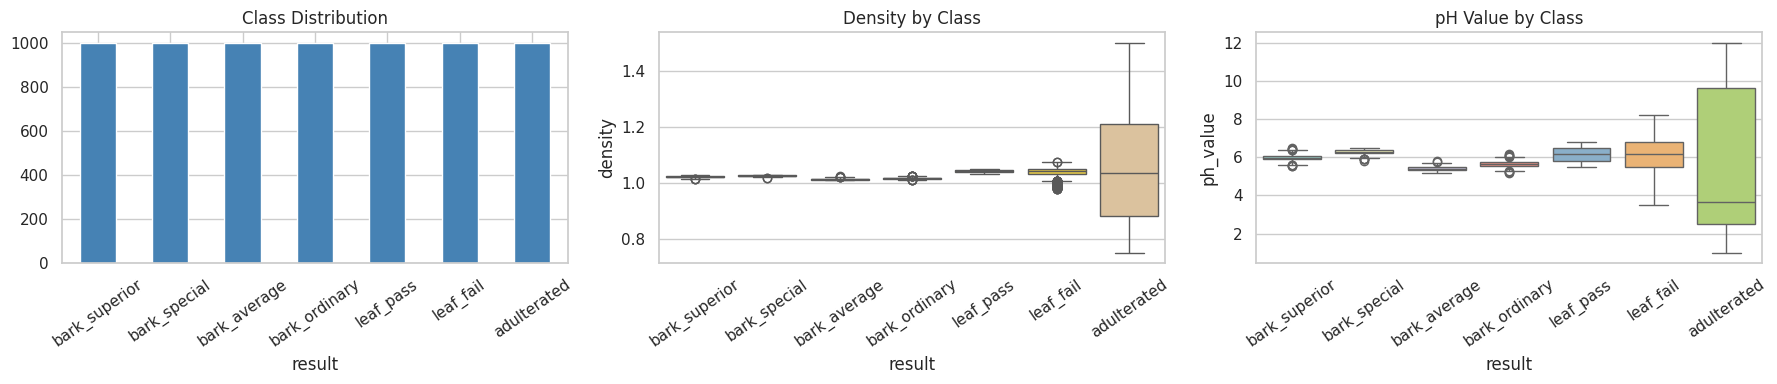

Missing values: None
Duplicate rows: 0


In [11]:
print("Class distribution:")
print(df_clean[TARGET_COLUMN].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df_clean[TARGET_COLUMN].value_counts().reindex(CLASS_NAMES, fill_value=0).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Class Distribution"); axes[0].tick_params(axis="x", rotation=35)

sns.boxplot(data=df_clean, x=TARGET_COLUMN, y="density",
            order=CLASS_NAMES, palette="Set2", ax=axes[1])
axes[1].set_title("Density by Class"); axes[1].tick_params(axis="x", rotation=35)

sns.boxplot(data=df_clean, x=TARGET_COLUMN, y="ph_value",
            order=CLASS_NAMES, palette="Set3", ax=axes[2])
axes[2].set_title("pH Value by Class"); axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout(); plt.show()

mv = df_clean.isnull().sum()
print("Missing values:", mv[mv > 0].to_dict() if mv.any() else "None")
print("Duplicate rows:", df_clean.duplicated().sum())


## 11. Encode labels

In [12]:
label_encoder = LabelEncoder()
label_encoder.fit(CLASS_NAMES)   # fit on ALL 7 so encoding is always stable

df_clean["target_encoded"] = label_encoder.transform(df_clean[TARGET_COLUMN].astype(str))
NUM_CLASSES = len(label_encoder.classes_)

joblib.dump(label_encoder, os.path.join(MODEL_DIR, "label_encoder.pkl"))

print("Classes:")
for i, c in enumerate(label_encoder.classes_):
    print(f"  {i} → {c}")


Classes:
  0 → adulterated
  1 → bark_average
  2 → bark_ordinary
  3 → bark_special
  4 → bark_superior
  5 → leaf_fail
  6 → leaf_pass


## 12. Feature Engineering
Expanding from 2 raw features to 8 engineered ones so the tabular models have
more signal to separate 7 classes. Each new feature captures a different aspect:
- **density_ph_ratio / ph_density_ratio** — relative relationship between the two measurements
- **density_sq / ph_sq** — second-order (quadratic) terms for curved decision boundaries
- **log_density / log_ph** — logarithmic transforms to compress outlier values
- **density_x_ph** — interaction term (joint effect)


In [13]:
def engineer_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Add interaction, polynomial, and log features to a copy of df_in."""
    d = df_in.copy()
    eps = 1e-8   # avoids log(0) / div-by-zero

    d["density_ph_ratio"]  = d["density"] / (d["ph_value"] + eps)
    d["ph_density_ratio"]  = d["ph_value"] / (d["density"] + eps)
    d["density_sq"]        = d["density"] ** 2
    d["ph_sq"]             = d["ph_value"] ** 2
    d["log_density"]       = np.log1p(d["density"].clip(lower=0))
    d["log_ph"]            = np.log1p(d["ph_value"].clip(lower=0))
    d["density_x_ph"]      = d["density"] * d["ph_value"]
    return d

df_clean = engineer_features(df_clean)

ALL_FEATURES = [
    "density", "ph_value",
    "density_ph_ratio", "ph_density_ratio",
    "density_sq", "ph_sq",
    "log_density", "log_ph",
    "density_x_ph",
]

# Keep only features that exist (in case CSV had extra cols)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_clean.columns]
print(f"Total engineered features: {len(ALL_FEATURES)}")
print(ALL_FEATURES)


Total engineered features: 9
['density', 'ph_value', 'density_ph_ratio', 'ph_density_ratio', 'density_sq', 'ph_sq', 'log_density', 'log_ph', 'density_x_ph']


## 13. Tabular train / val split

In [14]:
X_tabular = df_clean[ALL_FEATURES].copy()
y_encoded = df_clean["target_encoded"].values

X_train_tab, X_val_tab, y_train, y_val = train_test_split(
    X_tabular, y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

# Class weights for imbalanced datasets (used by XGBoost / CatBoost)
classes_arr  = np.unique(y_train)
class_weights = compute_class_weight("balanced", classes=classes_arr, y=y_train)
cw_dict = dict(zip(classes_arr.tolist(), class_weights.tolist()))
print("Train:", X_train_tab.shape, "| Val:", X_val_tab.shape)
print("Class weights:", cw_dict)


Train: (5600, 9) | Val: (1400, 9)
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}


## 14. Tabular preprocessing pipeline

In [15]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, ALL_FEATURES)],
    remainder="drop"
)

metadata = {
    "target_column"     : TARGET_COLUMN,
    "image_column"      : IMAGE_COLUMN,
    "numerical_features": NUMERICAL_FEATURES,
    "all_features"      : ALL_FEATURES,
    "class_names"       : CLASS_NAMES,
    "problem_type"      : "classification",
}
joblib.dump(metadata, os.path.join(MODEL_DIR, "metadata.pkl"))
print("Metadata saved.")


Metadata saved.


## 15. Evaluation helper

In [16]:
def evaluate_classification(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Weighted F1: {f1:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred,
                                target_names=label_encoder.classes_,
                                zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=30, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

    return {"model": model_name, "accuracy": acc, "f1": f1}

print("Evaluation helper ready.")


Evaluation helper ready.


## 16. Train tabular models with Stratified K-Fold CV
- **n_estimators** reduced (300→150 RF) to save RAM — still sufficient
- All models receive balanced class weights
- 5-fold CV gives a stable accuracy estimate, then a final model is fit on full train set



── RandomForest ──────────────────────────────────────────────
  CV F1 (weighted): 0.8983 ± 0.0065

  RandomForest
  Accuracy   : 0.8943
  Weighted F1: 0.8952
               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00       200
 bark_average       0.87      0.83      0.85       200
bark_ordinary       0.75      0.77      0.76       200
 bark_special       0.92      0.87      0.89       200
bark_superior       0.76      0.82      0.79       200
    leaf_fail       0.99      0.97      0.98       200
    leaf_pass       1.00      1.00      1.00       200

     accuracy                           0.89      1400
    macro avg       0.90      0.89      0.90      1400
 weighted avg       0.90      0.89      0.90      1400



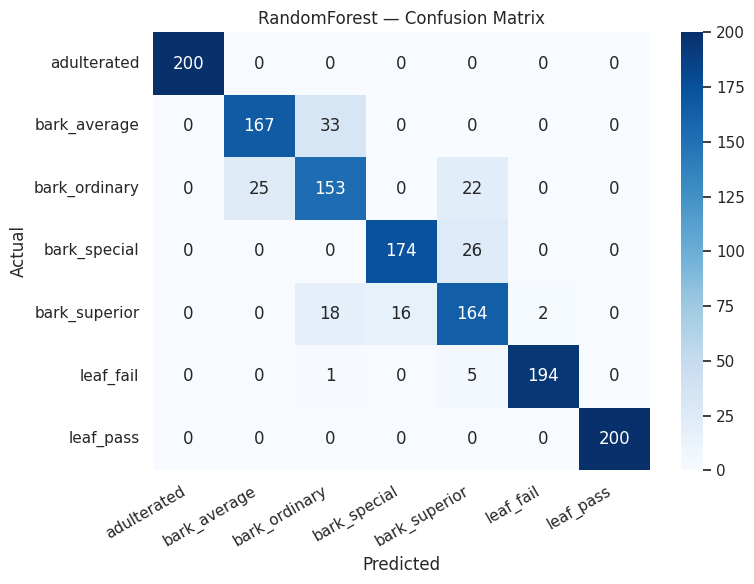


── XGBoost ──────────────────────────────────────────────
  CV F1 (weighted): 0.8999 ± 0.0057

  XGBoost
  Accuracy   : 0.8886
  Weighted F1: 0.8896
               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00       200
 bark_average       0.87      0.83      0.85       200
bark_ordinary       0.75      0.78      0.76       200
 bark_special       0.91      0.85      0.88       200
bark_superior       0.75      0.82      0.78       200
    leaf_fail       0.97      0.95      0.96       200
    leaf_pass       0.99      0.98      0.99       200

     accuracy                           0.89      1400
    macro avg       0.89      0.89      0.89      1400
 weighted avg       0.89      0.89      0.89      1400



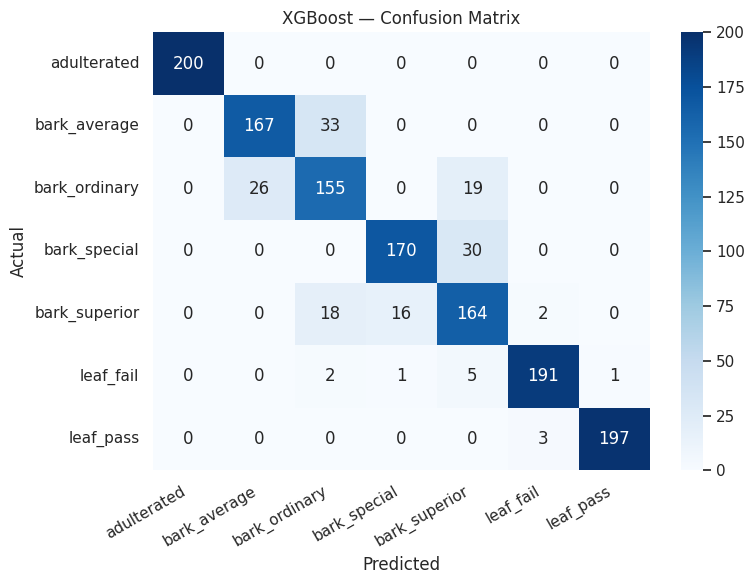


── CatBoost ──────────────────────────────────────────────
  CV F1 (weighted): 0.9078 ± 0.0052

  CatBoost
  Accuracy   : 0.9086
  Weighted F1: 0.9093
               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00       200
 bark_average       0.87      0.85      0.86       200
bark_ordinary       0.78      0.81      0.79       200
 bark_special       0.93      0.89      0.91       200
bark_superior       0.81      0.85      0.83       200
    leaf_fail       0.98      0.96      0.97       200
    leaf_pass       1.00      0.98      0.99       200

     accuracy                           0.91      1400
    macro avg       0.91      0.91      0.91      1400
 weighted avg       0.91      0.91      0.91      1400



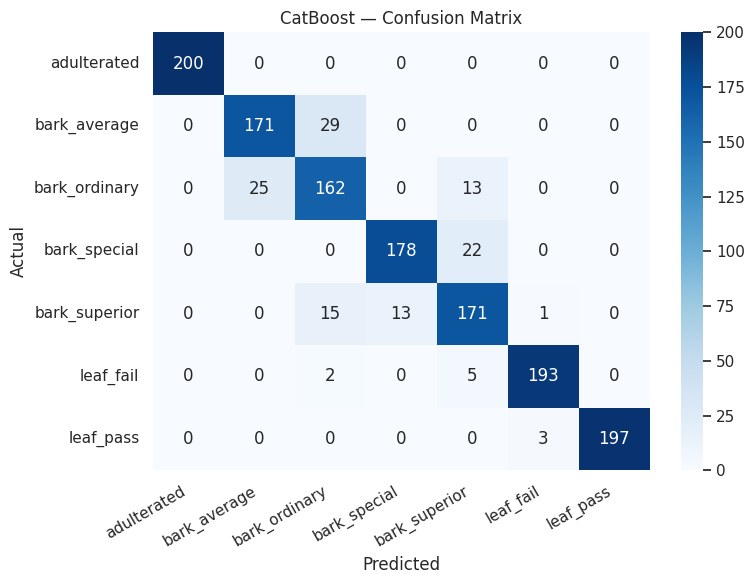


Tabular model comparison:


,model,accuracy,f1,cv_f1_mean,cv_f1_std
2,CatBoost,0.908571,0.909299,0.907821,0.005200
0,RandomForest,0.894286,0.895182,0.898303,0.006473
1,XGBoost,0.888571,0.889645,0.899866,0.005687


In [17]:
# Sample weights for sklearn models
sample_weights = np.array([cw_dict[y] for y in y_train])

models_cfg = {
    "RandomForest": RandomForestClassifier(
        n_estimators=150,          # 300→150 saves significant RAM
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        gamma=0.1,
        random_state=RANDOM_STATE,
        objective="multi:softprob",
        eval_metric="mlogloss",
        num_class=NUM_CLASSES,
        use_label_encoder=False,
        tree_method="hist",        # memory-efficient histogram method
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        loss_function="MultiClass",
        random_seed=RANDOM_STATE,
        verbose=False,
        auto_class_weights="Balanced",
    ),
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

tabular_results        = []
trained_tabular_models = {}

for model_name, base_model in models_cfg.items():
    print(f"\n── {model_name} ──────────────────────────────────────────────")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model",        base_model),
    ])

    # K-Fold CV on train set to get stable accuracy estimate
    cv_scores = cross_val_score(
        pipeline, X_train_tab, y_train,
        cv=skf, scoring="f1_weighted", n_jobs=-1
    )
    print(f"  CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Fit on full train set
    if model_name == "XGBoost":
        # XGBoost sample_weight goes through Pipeline differently
        pipeline.fit(X_train_tab, y_train,
                     model__sample_weight=sample_weights)
    else:
        pipeline.fit(X_train_tab, y_train)

    y_pred = pipeline.predict(X_val_tab)
    result = evaluate_classification(y_val, y_pred, model_name)
    result["cv_f1_mean"] = cv_scores.mean()
    result["cv_f1_std"]  = cv_scores.std()
    tabular_results.append(result)
    trained_tabular_models[model_name] = pipeline

    # Free memory between large models
    gc.collect()

tabular_results_df = pd.DataFrame(tabular_results).sort_values("f1", ascending=False)
print("\nTabular model comparison:")
display(tabular_results_df)


## 17. Select & save best tabular model

In [18]:
best_row                = tabular_results_df.iloc[0]
best_tabular_model_name = best_row["model"]
best_tabular_model      = trained_tabular_models[best_tabular_model_name]

print(f"Best tabular model : {best_tabular_model_name}")
print(f"  Val Accuracy : {best_row['accuracy']:.4f}")
print(f"  Val F1       : {best_row['f1']:.4f}")
print(f"  CV F1        : {best_row['cv_f1_mean']:.4f} ± {best_row['cv_f1_std']:.4f}")

joblib.dump(best_tabular_model, os.path.join(MODEL_DIR, "best_tabular_model.pkl"))
print("Saved →", os.path.join(MODEL_DIR, "best_tabular_model.pkl"))


Best tabular model : CatBoost
  Val Accuracy : 0.9086
  Val F1       : 0.9093
  CV F1        : 0.9078 ± 0.0052
Saved → /content/models/best_tabular_model.pkl


## 18. Feature importance

,feature,importance
6,log_density,19.166060
4,density_sq,18.480624
0,density,14.656621
1,ph_value,12.097117
8,density_x_ph,10.382006
5,ph_sq,7.799942
7,log_ph,6.730781
2,density_ph_ratio,5.533828
3,ph_density_ratio,5.153021


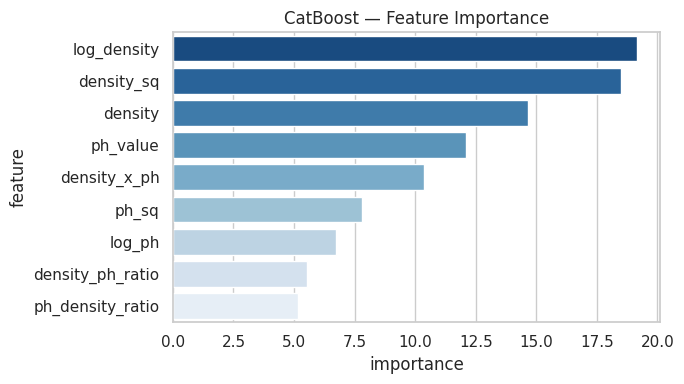

In [19]:
try:
    fitted = best_tabular_model.named_steps["model"]
    if hasattr(fitted, "feature_importances_"):
        imp_df = pd.DataFrame({
            "feature"   : ALL_FEATURES,
            "importance": fitted.feature_importances_
        }).sort_values("importance", ascending=False)
        display(imp_df)

        plt.figure(figsize=(7, 4))
        sns.barplot(data=imp_df, x="importance", y="feature", palette="Blues_r")
        plt.title(f"{best_tabular_model_name} — Feature Importance")
        plt.tight_layout(); plt.show()
    else:
        print(f"{best_tabular_model_name} has no feature_importances_.")
except Exception as e:
    print("Could not compute feature importances:", e)


## 19. Check image availability

In [20]:
if "image_path" not in df_img_clean.columns:
    df_img_clean["image_path"] = df_img_clean[IMAGE_COLUMN].apply(find_image_path)

USE_IMAGE_MODEL = len(df_img_clean) >= 20
print("Use image model:", USE_IMAGE_MODEL)
if not USE_IMAGE_MODEL:
    print(f"Only {len(df_img_clean)} images found (need ≥ 20). Skipping image & hybrid models.")

if USE_IMAGE_MODEL:
    # Apply feature engineering to image subset too
    df_img_clean = engineer_features(df_img_clean)
    df_img_clean["target_encoded"] = label_encoder.transform(
        df_img_clean[TARGET_COLUMN].astype(str))

    img_encoded = df_img_clean["target_encoded"].values
    train_img_df, val_img_df = train_test_split(
        df_img_clean, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=img_encoded
    )
    print("Image train:", train_img_df.shape, "| Val:", val_img_df.shape)


Use image model: True
Image train: (5600, 14) | Val: (1400, 14)


## 20. Build shared EfficientNetB0 backbone
Loading the backbone once and reusing it in both the image model and hybrid model
saves ~600MB GPU RAM vs the original approach of loading it twice.


In [21]:
shared_backbone = None  # will be set below if USE_IMAGE_MODEL

if USE_IMAGE_MODEL:
    shared_backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    shared_backbone.trainable = False   # Phase-1: frozen
    print("Shared backbone loaded — trainable layers:", sum(w.trainable for w in shared_backbone.weights))


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shared backbone loaded — trainable layers: 0


## 21. Streaming tf.data pipelines
**This is the key memory fix.** The original code called `load_image_arrays()` which
loaded the entire image set into a numpy array (train + val × float32 × 224×224×3 = OOM).

Now images are decoded on-the-fly using `tf.data`, so only one batch lives in memory at a time.
Shuffle buffer is capped at `MAX_SHUFFLE_BUF` so it never buffers the whole dataset.


In [22]:
def load_and_preprocess_image(path, target):
    """Decode + resize + normalise a single image on-the-fly."""
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, target

def make_image_dataset(dataframe, shuffle=True):
    """Build a streaming tf.data.Dataset — images never fully loaded into RAM."""
    paths   = dataframe["image_path"].values
    targets = label_encoder.transform(dataframe[TARGET_COLUMN].astype(str))
    ds = tf.data.Dataset.from_tensor_slices((paths, targets.astype(np.int32)))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        buf = min(MAX_SHUFFLE_BUF, len(dataframe))  # ← capped, prevents OOM
        ds = ds.shuffle(buffer_size=buf, seed=RANDOM_STATE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Hybrid needs image + tabular in parallel
def load_and_preprocess_image_tab(path, tab_features, target):
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return (image, tab_features), target

def make_hybrid_dataset(dataframe, tab_array, shuffle=True):
    """Build a streaming hybrid dataset — images decoded on-the-fly, tabular from array."""
    paths   = dataframe["image_path"].values
    targets = label_encoder.transform(dataframe[TARGET_COLUMN].astype(str))
    ds = tf.data.Dataset.from_tensor_slices((
        paths,
        tab_array.astype(np.float32),
        targets.astype(np.int32)
    ))
    ds = ds.map(load_and_preprocess_image_tab, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        buf = min(MAX_SHUFFLE_BUF, len(dataframe))
        ds = ds.shuffle(buffer_size=buf, seed=RANDOM_STATE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

if USE_IMAGE_MODEL:
    train_img_ds = make_image_dataset(train_img_df, shuffle=True)
    val_img_ds   = make_image_dataset(val_img_df,   shuffle=False)
    print("Image datasets ready — streaming, no full-RAM load.")


Image datasets ready — streaming, no full-RAM load.


## 22. Build image model (uses shared backbone)

In [23]:
def build_image_model(backbone):
    augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.12),
        layers.RandomBrightness(0.10),
    ], name="augmentation")

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="img_input")
    x      = augmentation(inputs)
    x      = backbone(x, training=False)    # training=False = frozen BN
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.Dropout(0.40)(x)
    x      = layers.Dense(256, activation="relu")(x)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dropout(0.30)(x)
    x      = layers.Dense(128, activation="relu")(x)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dropout(0.20)(x)
    # float32 output required when using mixed_float16
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = models.Model(inputs, outputs, name="image_model")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

if USE_IMAGE_MODEL:
    image_model = build_image_model(shared_backbone)
    image_model.summary(line_length=100)


Model: "image_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input (InputLayer)                     │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ augmentation (Sequential)                  │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ efficientnetb0 (Functional)                │ (None, 7, 7, 1280)              │         4,049,571 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 1280)                    │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 1280)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 256)                     │           327,936 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization (BatchNormalization)   │ (None, 256)                     │             1,024 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 128)                     │            32,896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_1 (BatchNormalization) │ (None, 128)                     │               512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_2 (Dropout)                        │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_2 (Dense)                            │ (None, 7)                       │               903 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 4,412,842 (16.83 MB)

 Trainable params: 362,503 (1.38 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

## 23. Train image model — two-phase fine-tuning
**Phase 1 (frozen backbone):** fast warm-up, only the new head trains.  
**Phase 2 (unfreeze top-30 layers):** fine-tune the upper conv blocks at a lower LR.  
This was missing in the original and is the biggest accuracy gain for image models.


In [24]:
image_history_p1 = None
image_history_p2 = None

if USE_IMAGE_MODEL:
    img_model_path = os.path.join(MODEL_DIR, "best_image_model.keras")
    common_cbs = [
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
        ModelCheckpoint(img_model_path, monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7),
    ]

    # ── Phase 1: backbone frozen ──────────────────────────────────────────
    print("Phase 1: frozen backbone")
    image_history_p1 = image_model.fit(
        train_img_ds, validation_data=val_img_ds,
        epochs=20, callbacks=common_cbs
    )

    # ── Phase 2: unfreeze top-30 backbone layers ──────────────────────────
    print("\nPhase 2: fine-tuning top-30 backbone layers")
    shared_backbone.trainable = True
    for layer in shared_backbone.layers[:-30]:
        layer.trainable = False

    # Recompile at a lower LR for fine-tuning
    image_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    common_cbs2 = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ModelCheckpoint(img_model_path, monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-8),
    ]

    image_history_p2 = image_model.fit(
        train_img_ds, validation_data=val_img_ds,
        epochs=EPOCHS, callbacks=common_cbs2
    )

    image_model = tf.keras.models.load_model(img_model_path)
    # Re-freeze backbone for hybrid reuse
    shared_backbone.trainable = False


Phase 1: frozen backbone
Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 119ms/step - accuracy: 0.1443 - loss: 2.4089 - val_accuracy: 0.1429 - val_loss: 2.1722 - learning_rate: 0.0010
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1416 - loss: 2.1387 - val_accuracy: 0.1429 - val_loss: 1.9706 - learning_rate: 0.0010
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.1437 - loss: 2.0609 - val_accuracy: 0.1429 - val_loss: 1.9574 - learning_rate: 0.0010
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.1398 - loss: 2.0144 - val_accuracy: 0.1429 - val_loss: 1.9559 - learning_rate: 0.0010
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.1493 - loss: 1.9959 - val_accuracy: 0.1429 - val_loss: 1.9461 - learning_rate: 0.0010
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.1464 - loss: 1.9865 - val_accuracy: 0.1429 - val_loss: 1.9473 - learning_rate: 0.0010
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/s

## 24. Image model training curves

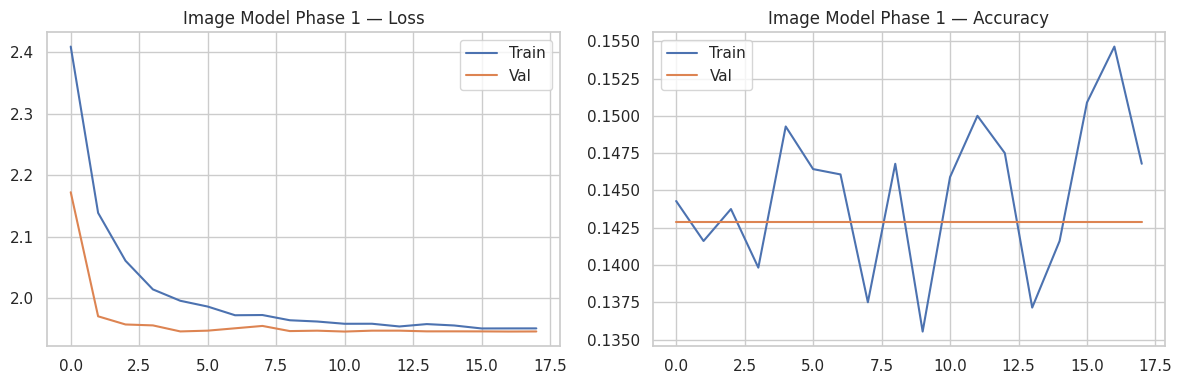

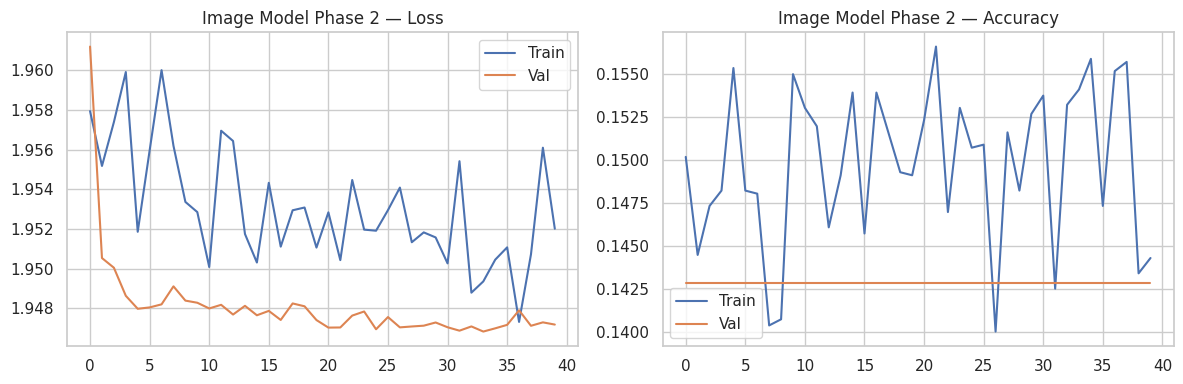

In [25]:
def plot_history(history, title):
    if history is None:
        return
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["loss"], label="Train"); axes[0].plot(h["val_loss"], label="Val")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend()
    if "accuracy" in h:
        axes[1].plot(h["accuracy"], label="Train"); axes[1].plot(h["val_accuracy"], label="Val")
        axes[1].set_title(f"{title} — Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(image_history_p1, "Image Model Phase 1")
plot_history(image_history_p2, "Image Model Phase 2")


## 25. Evaluate image model

88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step

  Image Model
  Accuracy   : 0.1429
  Weighted F1: 0.0357
               precision    recall  f1-score   support

  adulterated       0.00      0.00      0.00       200
 bark_average       0.00      0.00      0.00       200
bark_ordinary       0.00      0.00      0.00       200
 bark_special       0.14      1.00      0.25       200
bark_superior       0.00      0.00      0.00       200
    leaf_fail       0.00      0.00      0.00       200
    leaf_pass       0.00      0.00      0.00       200

     accuracy                           0.14      1400
    macro avg       0.02      0.14      0.04      1400
 weighted avg       0.02      0.14      0.04      1400



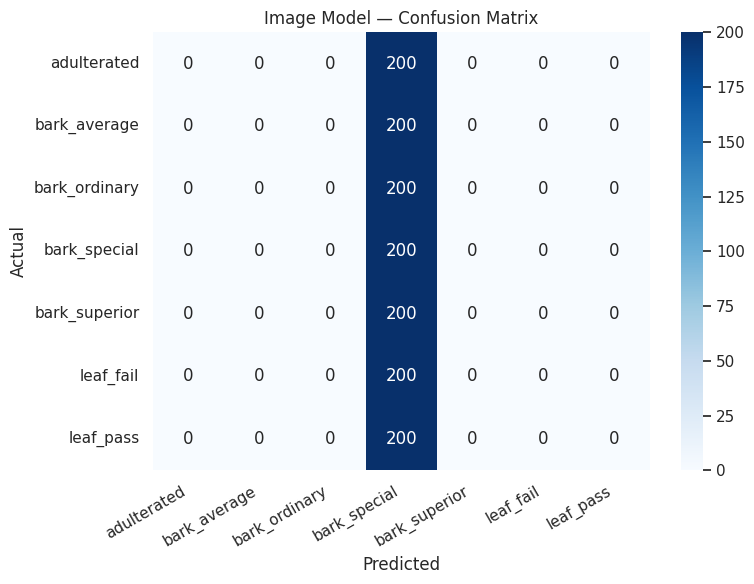

In [26]:
image_result = None

if USE_IMAGE_MODEL:
    y_val_img_true = label_encoder.transform(val_img_df[TARGET_COLUMN].astype(str))
    img_preds_raw  = image_model.predict(val_img_ds)
    img_preds      = np.argmax(img_preds_raw, axis=1)
    image_result   = evaluate_classification(y_val_img_true, img_preds, "Image Model")
else:
    print("Image model skipped.")


## 26. Hybrid model — tabular preprocessing

In [27]:
USE_HYBRID_MODEL = USE_IMAGE_MODEL and len(ALL_FEATURES) > 0
print("Use hybrid model:", USE_HYBRID_MODEL)

if USE_HYBRID_MODEL:
    hybrid_df     = df_img_clean.copy()
    hybrid_target = hybrid_df["target_encoded"].values

    train_h_df, val_h_df = train_test_split(
        hybrid_df, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=hybrid_target
    )

    hybrid_preprocessor = ColumnTransformer(
        transformers=[("num", numeric_transformer, ALL_FEATURES)],
        remainder="drop"
    )

    X_train_h_tab = hybrid_preprocessor.fit_transform(
        train_h_df[ALL_FEATURES]).astype(np.float32)
    X_val_h_tab   = hybrid_preprocessor.transform(
        val_h_df[ALL_FEATURES]).astype(np.float32)

    y_train_h = label_encoder.transform(train_h_df[TARGET_COLUMN].astype(str))
    y_val_h   = label_encoder.transform(val_h_df[TARGET_COLUMN].astype(str))

    joblib.dump(hybrid_preprocessor,
                os.path.join(MODEL_DIR, "hybrid_tabular_preprocessor.pkl"))

    # Build streaming hybrid datasets (no numpy image arrays)
    train_hyb_ds = make_hybrid_dataset(train_h_df, X_train_h_tab, shuffle=True)
    val_hyb_ds   = make_hybrid_dataset(val_h_df,   X_val_h_tab,   shuffle=False)

    print("Hybrid tabular shape — train:", X_train_h_tab.shape, "| val:", X_val_h_tab.shape)
    print("Streaming hybrid datasets ready.")


Use hybrid model: True
Hybrid tabular shape — train: (5600, 9) | val: (1400, 9)
Streaming hybrid datasets ready.


## 27. Build hybrid model (reuses shared backbone)
The backbone is the **same Python object** as used by the image model —
it is not re-downloaded or re-instantiated.  This saves a full copy of
EfficientNetB0 from GPU memory.


In [28]:
def build_hybrid_model(backbone, tabular_dim):
    augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.12),
    ], name="hybrid_aug")

    # ── Image branch ──────────────────────────────────────────────────────
    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x_img     = augmentation(img_input)
    x_img     = backbone(x_img, training=False)
    x_img     = layers.GlobalAveragePooling2D()(x_img)
    x_img     = layers.Dropout(0.40)(x_img)
    x_img     = layers.Dense(256, activation="relu")(x_img)
    x_img     = layers.BatchNormalization()(x_img)
    x_img     = layers.Dropout(0.25)(x_img)
    x_img     = layers.Dense(128, activation="relu", name="img_embed")(x_img)

    # ── Tabular branch ────────────────────────────────────────────────────
    tab_input = layers.Input(shape=(tabular_dim,), name="tabular_input")
    x_tab     = layers.Dense(128, activation="relu")(tab_input)   # wider (was 64)
    x_tab     = layers.BatchNormalization()(x_tab)
    x_tab     = layers.Dropout(0.30)(x_tab)
    x_tab     = layers.Dense(64, activation="relu")(x_tab)
    x_tab     = layers.BatchNormalization()(x_tab)
    x_tab     = layers.Dropout(0.20)(x_tab)
    x_tab     = layers.Dense(32, activation="relu", name="tab_embed")(x_tab)

    # ── Fusion ────────────────────────────────────────────────────────────
    combined = layers.concatenate([x_img, x_tab])
    x = layers.Dense(256, activation="relu")(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation="relu")(x)

    output = layers.Dense(NUM_CLASSES, activation="softmax",
                          dtype="float32", name="predictions")(x)

    model = models.Model(inputs=[img_input, tab_input], outputs=output,
                         name="hybrid_model")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

if USE_HYBRID_MODEL:
    hybrid_model = build_hybrid_model(shared_backbone, X_train_h_tab.shape[1])
    hybrid_model.summary(line_length=100)


Model: "hybrid_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)    │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ hybrid_aug (Sequential)     │ (None, 224, 224, 3)     │              0 │ image_input[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ tabular_input (InputLayer)  │ (None, 9)               │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ efficientnetb0 (Functional) │ (None, 7, 7, 1280)      │      4,049,571 │ hybrid_aug[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dense_4 (Dense)             │ (None, 128)             │          1,280 │ tabular_input[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ global_average_pooling2d_1  │ (None, 1280)            │              0 │ efficientnetb0[1][0]    │
│ (GlobalAveragePooling2D)    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_3       │ (None, 128)             │            512 │ dense_4[0][0]           │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout_3 (Dropout)         │ (None, 1280)            │              0 │ global_average_pooling… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout_5 (Dropout)         │ (None, 128)             │              0 │ batch_normalization_3[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dense_3 (Dense)             │ (None, 256)             │        327,936 │ dropout_3[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dense_5 (Dense)             │ (None, 64)              │          8,256 │ dropout_5[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_2       │ (None, 256)             │          1,024 │ dense_3[0][0]           │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_4       │ (None, 64)              │            256 │ dense_5[0][0]           │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout_4 (Dropout)         │ (None, 256)             │              0 │ batch_normalization_2[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout_6 (Dropout)         │ (None, 64)              │              0 │ batch_normalization_4[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ img_embed (Dense)           │ (None, 128)             │         32,896 │ dropout_4[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ tab_embed (Dense)           │ (None, 32)              │    

 Total params: 4,508,170 (17.20 MB)

 Trainable params: 456,935 (1.74 MB)

 Non-trainable params: 4,051,235 (15.45 MB)

## 28. Train hybrid model

Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 76ms/step - accuracy: 0.3702 - loss: 1.5932 - val_accuracy: 0.3764 - val_loss: 1.2591 - learning_rate: 5.0000e-04
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.5927 - loss: 1.0046 - val_accuracy: 0.7864 - val_loss: 0.5879 - learning_rate: 5.0000e-04
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.6571 - loss: 0.8498 - val_accuracy: 0.8336 - val_loss: 0.4661 - learning_rate: 5.0000e-04
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.6995 - loss: 0.7499 - val_accuracy: 0.8400 - val_loss: 0.4743 - learning_rate: 5.0000e-04
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.7146 - loss: 0.7003 - val_accuracy: 0.8750 - val_loss: 0.3735 - learning_rate: 5.0000e-04
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 24s 64ms/step - accuracy: 0.7268 - loss: 0.6642 - val_accuracy: 0.8593 - val_loss: 0.4038 - learning_rate: 5.0000e-04
Epoch 7/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/ste

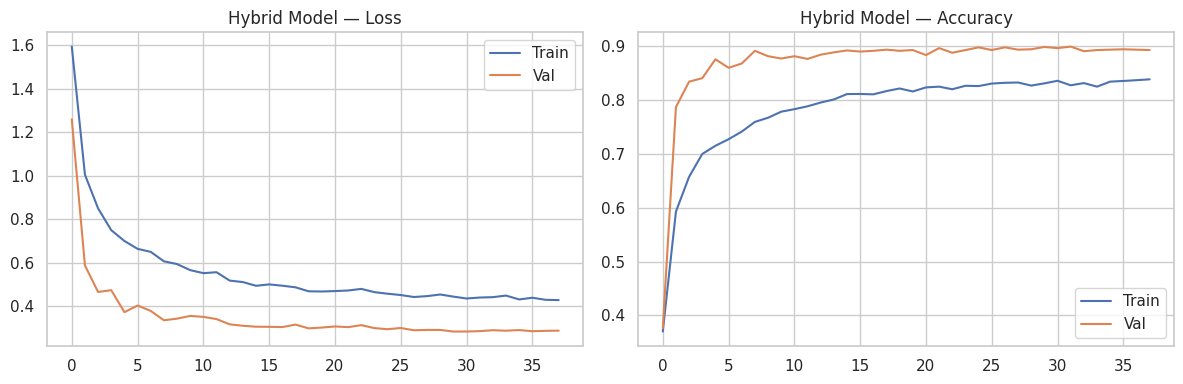

In [29]:
hybrid_history = None

if USE_HYBRID_MODEL:
    hybrid_model_path = os.path.join(MODEL_DIR, "best_hybrid_model.keras")

    hybrid_cbs = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ModelCheckpoint(hybrid_model_path, monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, min_lr=1e-8),
    ]

    hybrid_history = hybrid_model.fit(
        train_hyb_ds,
        validation_data=val_hyb_ds,
        epochs=EPOCHS,
        callbacks=hybrid_cbs,
    )

    hybrid_model = tf.keras.models.load_model(hybrid_model_path)
    gc.collect()

plot_history(hybrid_history, "Hybrid Model")


## 29. Evaluate hybrid model

88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step

  Hybrid Model
  Accuracy   : 0.8979
  Weighted F1: 0.8980
               precision    recall  f1-score   support

  adulterated       1.00      1.00      1.00       200
 bark_average       0.88      0.88      0.88       200
bark_ordinary       0.79      0.79      0.79       200
 bark_special       0.88      0.92      0.90       200
bark_superior       0.80      0.81      0.80       200
    leaf_fail       1.00      0.90      0.95       200
    leaf_pass       0.96      1.00      0.98       200

     accuracy                           0.90      1400
    macro avg       0.90      0.90      0.90      1400
 weighted avg       0.90      0.90      0.90      1400



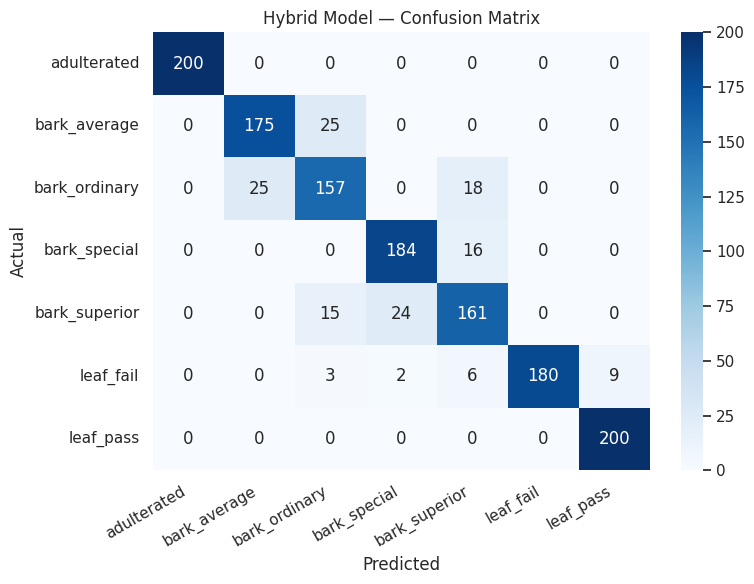

In [30]:
hybrid_result = None

if USE_HYBRID_MODEL:
    hybrid_preds_raw = hybrid_model.predict(val_hyb_ds)
    hybrid_preds     = np.argmax(hybrid_preds_raw, axis=1)
    hybrid_result    = evaluate_classification(y_val_h, hybrid_preds, "Hybrid Model")
else:
    print("Hybrid model skipped.")


## 30. Compare all models

Model comparison (sorted by Weighted F1):


,model,accuracy,f1,cv_f1_mean,cv_f1_std
2,CatBoost,0.908571,0.909299,0.907821,0.005200
4,Hybrid Model,0.897857,0.897988,NaN,NaN
0,RandomForest,0.894286,0.895182,0.898303,0.006473
1,XGBoost,0.888571,0.889645,0.899866,0.005687
3,Image Model,0.142857,0.035714,NaN,NaN



★ Best overall model: CatBoost


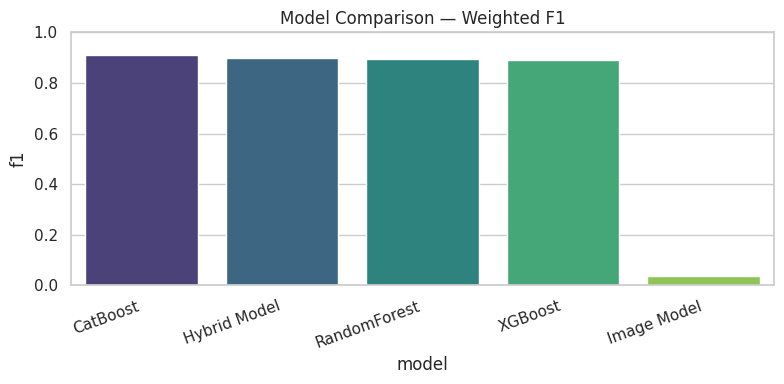

In [31]:
all_results = list(tabular_results)
if image_result  is not None: all_results.append(image_result)
if hybrid_result is not None: all_results.append(hybrid_result)

comparison_df = pd.DataFrame(all_results).sort_values("f1", ascending=False)
print("Model comparison (sorted by Weighted F1):")
display(comparison_df)

best_overall_name = comparison_df.iloc[0]["model"]
print("\n★ Best overall model:", best_overall_name)

# Bar chart
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x="model", y="f1", palette="viridis")
plt.title("Model Comparison — Weighted F1"); plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()


## 31. Export all artefacts

In [32]:
EXPORT_DIR = "/content/final_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

export_summary = {
    "problem_type"      : "classification",
    "target_column"     : TARGET_COLUMN,
    "image_column"      : IMAGE_COLUMN,
    "numerical_features": NUMERICAL_FEATURES,
    "all_features"      : ALL_FEATURES,
    "class_names"       : CLASS_NAMES,
    "best_overall_model": best_overall_name,
}

# Best tabular model
tab_path = os.path.join(EXPORT_DIR, "best_tabular_model.pkl")
joblib.dump(best_tabular_model, tab_path)
export_summary["best_tabular_model"] = {"name": best_tabular_model_name, "path": tab_path}
print("Saved:", tab_path)

# Image model
if USE_IMAGE_MODEL:
    img_path = os.path.join(EXPORT_DIR, "best_image_model.keras")
    image_model.save(img_path)
    export_summary["best_image_model"] = {"name": "Image Model", "path": img_path}
    print("Saved:", img_path)

# Hybrid model
if USE_HYBRID_MODEL:
    hyb_path = os.path.join(EXPORT_DIR, "best_hybrid_model.keras")
    hybrid_model.save(hyb_path)
    export_summary["best_hybrid_model"] = {"name": "Hybrid Model", "path": hyb_path}
    print("Saved:", hyb_path)

# Encoders & preprocessors
le_path = os.path.join(EXPORT_DIR, "label_encoder.pkl")
joblib.dump(label_encoder, le_path); print("Saved:", le_path)

pp_path = os.path.join(EXPORT_DIR, "tabular_preprocessor.pkl")
joblib.dump(preprocessor, pp_path); print("Saved:", pp_path)

if USE_HYBRID_MODEL:
    hpp_path = os.path.join(EXPORT_DIR, "hybrid_tabular_preprocessor.pkl")
    joblib.dump(hybrid_preprocessor, hpp_path); print("Saved:", hpp_path)

# Comparison CSV
cmp_path = os.path.join(EXPORT_DIR, "model_comparison.csv")
comparison_df.to_csv(cmp_path, index=False); print("Saved:", cmp_path)

# Summary JSON
with open(os.path.join(EXPORT_DIR, "model_summary.json"), "w") as f:
    json.dump(export_summary, f, indent=4)

print("\n✓ All exports done →", EXPORT_DIR)


Saved: /content/final_export/best_tabular_model.pkl
Saved: /content/final_export/best_image_model.keras
Saved: /content/final_export/best_hybrid_model.keras
Saved: /content/final_export/label_encoder.pkl
Saved: /content/final_export/tabular_preprocessor.pkl
Saved: /content/final_export/hybrid_tabular_preprocessor.pkl
Saved: /content/final_export/model_comparison.csv

✓ All exports done → /content/final_export


## 32. Save predictions CSV

In [33]:
if best_overall_name in trained_tabular_models:
    final_preds = trained_tabular_models[best_overall_name].predict(X_val_tab)
    pred_df = X_val_tab.copy()
    pred_df["actual_label"]    = label_encoder.inverse_transform(y_val.astype(int))
    pred_df["predicted_label"] = label_encoder.inverse_transform(final_preds.astype(int))
    pred_df["correct"]         = pred_df["actual_label"] == pred_df["predicted_label"]

elif best_overall_name == "Image Model":
    raw  = image_model.predict(val_img_ds)
    pred = np.argmax(raw, axis=1)
    y_img_true = label_encoder.transform(val_img_df[TARGET_COLUMN].astype(str))
    pred_df = val_img_df[[IMAGE_COLUMN, "density", "ph_value", TARGET_COLUMN]].copy()
    pred_df["actual_label"]    = label_encoder.inverse_transform(y_img_true.astype(int))
    pred_df["predicted_label"] = label_encoder.inverse_transform(pred.astype(int))
    pred_df["correct"]         = pred_df["actual_label"] == pred_df["predicted_label"]

elif best_overall_name == "Hybrid Model":
    raw  = hybrid_model.predict(val_hyb_ds)
    pred = np.argmax(raw, axis=1)
    pred_df = val_h_df[[IMAGE_COLUMN, "density", "ph_value", TARGET_COLUMN]].copy()
    pred_df["actual_label"]    = label_encoder.inverse_transform(y_val_h.astype(int))
    pred_df["predicted_label"] = label_encoder.inverse_transform(pred.astype(int))
    pred_df["correct"]         = pred_df["actual_label"] == pred_df["predicted_label"]

pred_path = os.path.join(OUTPUT_DIR, "predictions.csv")
pred_df.to_csv(pred_path, index=False)
print("Saved predictions →", pred_path)
print(f"Accuracy on val set: {pred_df['correct'].mean():.4f}")
display(pred_df.head(10))


Saved predictions → /content/outputs/predictions.csv
Accuracy on val set: 0.9086


,density,ph_value,density_ph_ratio,ph_density_ratio,density_sq,ph_sq,log_density,log_ph,density_x_ph,actual_label,predicted_label,correct
2614,1.2982,1.47,0.883129,1.132337,1.685323,2.1609,0.832126,0.904218,1.908354,adulterated,adulterated,True
2099,1.2938,1.20,1.078167,0.927500,1.673918,1.4400,0.830210,0.788457,1.552560,adulterated,adulterated,True
2763,0.7960,9.59,0.083003,12.047739,0.633616,91.9681,0.585562,2.359910,7.633640,adulterated,adulterated,True
519,1.0472,5.76,0.181806,5.500382,1.096628,33.1776,0.716473,1.911023,6.031872,leaf_pass,leaf_pass,True
2681,1.1213,3.80,0.295079,3.388924,1.257314,14.4400,0.752029,1.568616,4.260940,adulterated,adulterated,True
4302,1.0153,5.50,0.184600,5.417118,1.030834,30.2500,0.700768,1.871802,5.584150,bark_ordinary,bark_average,False
4653,1.0207,5.77,0.176898,5.652983,1.041828,33.2929,0.703444,1.912501,5.889439,bark_ordinary,bark_ordinary,True
6947,1.0276,6.33,0.162338,6.159984,1.055962,40.0689,0.706853,1.991976,6.504708,bark_special,bark_special,True
282,1.0378,6.06,0.171254,5.839275,1.077029,36.7236,0.711871,1.954445,6.289068,leaf_pass,leaf_pass,True
5926,1.0240,5.90,0.173559,5.761719,1.048576,34.8100,0.705076,1.931521,6.041600,bark_superior,bark_superior,True


## 33. Single-sample prediction helper

In [34]:
def predict_oil_type(density: float, ph_value: float, image_path: str = None) -> dict:
    """
    Predict cinnamon oil type from density + ph_value (and optional image).

    Returns:
        predicted_label  : one of the 7 class names
        confidence       : probability of top prediction
        all_probabilities: dict {class: probability}
    """
    # Build engineered feature row
    row = {"density": density, "ph_value": ph_value}
    sample_df = pd.DataFrame([row])
    sample_df = engineer_features(sample_df)
    sample_df = sample_df[ALL_FEATURES]

    model     = trained_tabular_models[best_tabular_model_name]
    pred_idx  = model.predict(sample_df)[0]
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    proba_dict = {}
    confidence = None
    if hasattr(model, "predict_proba"):
        probas     = model.predict_proba(sample_df)[0]
        proba_dict = {label_encoder.classes_[i]: round(float(p), 4)
                      for i, p in enumerate(probas)}
        confidence = round(float(probas[pred_idx]), 4)

    return {
        "predicted_label"  : pred_label,
        "confidence"       : confidence,
        "all_probabilities": proba_dict,
    }

# ── Quick test ─────────────────────────────────────────────────────────────
result = predict_oil_type(density=1.042, ph_value=5.35)
print(f"Input   : density=1.042, ph_value=5.35")
print(f"Result  : {result['predicted_label']}  (confidence: {result['confidence']})")
print("\nAll probabilities:")
for cls, p in sorted(result["all_probabilities"].items(), key=lambda x: -x[1]):
    bar = "█" * int(p * 30)
    print(f"  {cls:20s}: {p:.4f}  {bar}")


Input   : density=1.042, ph_value=5.35
Result  : leaf_fail  (confidence: 0.9834)

All probabilities:
  leaf_fail           : 0.9834  █████████████████████████████
  leaf_pass           : 0.0089  
  adulterated         : 0.0054  
  bark_ordinary       : 0.0009  
  bark_average        : 0.0008  
  bark_superior       : 0.0004  
  bark_special        : 0.0003  


## 34. Zip & download

In [35]:
!zip -r final_cinnamon_oil_models.zip /content/final_export
print("Archive created: final_cinnamon_oil_models.zip")


  adding: content/final_export/ (stored 0%)
  adding: content/final_export/model_summary.json (deflated 68%)
  adding: content/final_export/best_image_model.keras (deflated 10%)
  adding: content/final_export/model_comparison.csv (deflated 43%)
  adding: content/final_export/best_hybrid_model.keras (deflated 11%)
  adding: content/final_export/best_tabular_model.pkl (deflated 76%)
  adding: content/final_export/label_encoder.pkl (deflated 51%)
  adding: content/final_export/hybrid_tabular_preprocessor.pkl (deflated 48%)
  adding: content/final_export/tabular_preprocessor.pkl (deflated 48%)
Archive created: final_cinnamon_oil_models.zip


In [36]:
from google.colab import files
files.download("final_cinnamon_oil_models.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>